In [ ]:
!pip -q install tensorflow pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import os
import requests

data_dir = "/content/cmapss"
os.makedirs(data_dir, exist_ok=True)

base_url = "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/"

files = [
    "train_FD001.txt",
    "test_FD001.txt",
    "RUL_FD001.txt"
]

for file in files:
    path = os.path.join(data_dir, file)

    if not os.path.exists(path):
        url = base_url + file
        r = requests.get(url)
        r.raise_for_status()

        with open(path, "wb") as f:
            f.write(r.content)

    print("Ready:", path)

Ready: /content/cmapss/train_FD001.txt
Ready: /content/cmapss/test_FD001.txt
Ready: /content/cmapss/RUL_FD001.txt


In [ ]:
import pandas as pd
import os

train_path = "/content/cmapss/train_FD001.txt"
test_path  = "/content/cmapss/test_FD001.txt"
rul_path   = "/content/cmapss/RUL_FD001.txt"

cols = (
    ["unit", "cycle", "setting1", "setting2", "setting3"] +
    [f"s{i}" for i in range(1, 22)]
)

train = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None,
    names=cols
)

test = pd.read_csv(
    test_path,
    sep=r"\s+",
    header=None,
    names=cols
)

true_rul = pd.read_csv(
    rul_path,
    header=None,
    names=["RUL"]
)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("RUL shape  :", true_rul.shape)

display(train.head())
display(true_rul.head())

Train shape: (20631, 26)
Test shape : (13096, 26)
RUL shape  : (100, 1)


,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,RUL
0,112
1,98
2,69
3,82
4,91


In [ ]:
MAX_RUL = 125

train["RUL"] = (
    train.groupby("unit")["cycle"]
    .transform("max") - train["cycle"]
)

train["RUL"] = train["RUL"].clip(upper=MAX_RUL)

print(train[["unit", "cycle", "RUL"]].head(10))

   unit  cycle  RUL
0     1      1  125
1     1      2  125
2     1      3  125
3     1      4  125
4     1      5  125
5     1      6  125
6     1      7  125
7     1      8  125
8     1      9  125
9     1     10  125


In [ ]:
from sklearn.preprocessing import MinMaxScaler

sensor_cols = [f"s{i}" for i in range(1, 22)]

variances = train[sensor_cols].var()

useful_sensors = variances[variances > 1e-5].index.tolist()

print("Useful sensors:", useful_sensors)
print("Number of sensors:", len(useful_sensors))

scaler = MinMaxScaler()

train[useful_sensors] = scaler.fit_transform(
    train[useful_sensors]
)

test[useful_sensors] = scaler.transform(
    test[useful_sensors]
)

print(train[useful_sensors].describe())

Useful sensors: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Number of sensors: 14
                 s2            s3            s4            s7            s8  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.000000   
mean       0.443052      0.424746      0.450435      0.566459      0.297957   
std        0.150618      0.133664      0.151935      0.142527      0.107554   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.335843      0.331807      0.339467      0.476651      0.227273   
50%        0.430723      0.415522      0.435348      0.578100      0.287879   
75%        0.539157      0.508829      0.545324      0.669887      0.363636   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

                 s9           s11           s12           s13           s14  \
count  20631.000000  20631.000000  20631.000000  20631.000000  20631.000000   

In [ ]:
WINDOW = 30

def make_sequences(df, window=30):

    X = []
    y = []

    for unit in df["unit"].unique():

        engine = df[df["unit"] == unit].sort_values("cycle")

        values = engine[useful_sensors].values
        rul = engine["RUL"].values

        for i in range(len(engine) - window + 1):

            X.append(
                values[i:i+window]
            )

            y.append(
                rul[i+window-1]
            )

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_all, y_all = make_sequences(train, WINDOW)

print("Sequence shape:", X_all.shape)
print("RUL shape:", y_all.shape)

Sequence shape: (17731, 30, 14)
RUL shape: (17731,)


In [ ]:
engine_ids = sorted(train["unit"].unique())

train_engines = engine_ids[:80]
val_engines = engine_ids[80:]

train_df = train[train["unit"].isin(train_engines)]
val_df = train[train["unit"].isin(val_engines)]

X_train, y_train = make_sequences(train_df, WINDOW)
X_val, y_val = make_sequences(val_df, WINDOW)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

Training: (13818, 30, 14) (13818,)
Validation: (3913, 30, 14) (3913,)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

n_features = X_train.shape[2]
latent_dim = 16

# Encoder
encoder_inputs = layers.Input(
    shape=(WINDOW, n_features)
)

x = layers.LSTM(64)(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sample_latent(args):
    mean, log_var = args
    epsilon = tf.random.normal(
        shape=tf.shape(mean)
    )
    return mean + tf.exp(0.5 * log_var) * epsilon

z = layers.Lambda(
    sample_latent
)([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

# Decoder
decoder_inputs = layers.Input(
    shape=(latent_dim,)
)

x = layers.RepeatVector(WINDOW)(
    decoder_inputs
)

x = layers.LSTM(
    64,
    return_sequences=True
)(x)

decoder_outputs = layers.TimeDistributed(
    layers.Dense(n_features, activation="sigmoid")
)(x)

decoder = Model(
    decoder_inputs,
    decoder_outputs,
    name="decoder"
)

# VAE model
class VAE(Model):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):

        mean, log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.square(inputs - reconstructed),
                axis=[1, 2]
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + log_var
                - tf.square(mean)
                - tf.exp(log_var),
                axis=1
            )
        )

        self.add_loss(
            reconstruction_loss + 0.001 * kl_loss
        )

        return reconstructed


vae = VAE(encoder, decoder)

vae.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
)

vae.summary()

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 16), (None,    │        22,304 │
│                                 │ 16), (None, 16))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 30, 14)         │        21,646 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,950 (171.68 KB)

 Trainable params: 43,950 (171.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 4.8186 - val_loss: 2.4335
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 2.5044 - val_loss: 2.3346
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.3467 - val_loss: 2.1296
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.0403 - val_loss: 2.0014
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.9817 - val_loss: 1.9792
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.9693 - val_loss: 1.9680
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.9608 - val_loss: 1.9678
Epoch 8/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.9582 - val_loss: 1.9632
Epoch 9/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.9522 - val_loss: 1.9564
Epoch 10/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.9462 - val_loss: 1.9555
Epoch 11/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.9426 - val_loss: 1.9447
Epoch 12/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 

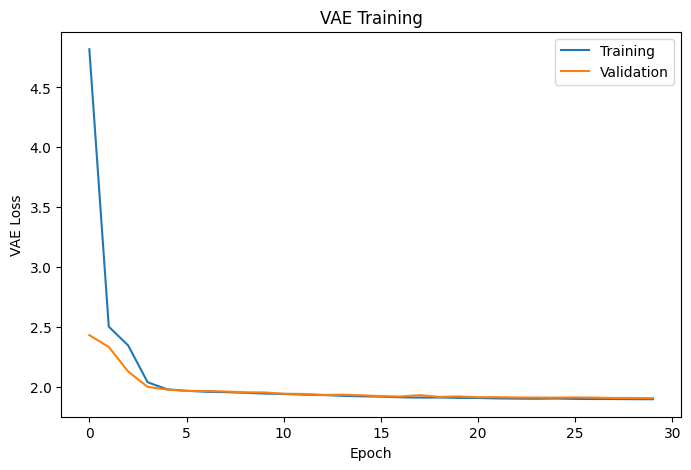

In [ ]:
history_vae = vae.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=128,
    shuffle=True,
    verbose=1
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_vae.history["loss"],
    label="Training"
)

plt.plot(
    history_vae.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("VAE Loss")
plt.title("VAE Training")
plt.legend()
plt.show()

In [ ]:
# Encode training sequences
z_mean, z_log_var, z = encoder.predict(
    X_train,
    batch_size=256,
    verbose=1
)

# Add controlled latent noise
noise = np.random.normal(
    0,
    0.15,
    size=z.shape
)

z_synthetic = z + noise

# Decode synthetic trajectories
X_synthetic = decoder.predict(
    z_synthetic,
    batch_size=256,
    verbose=1
)

# Keep labels associated with the corresponding trajectory
y_synthetic = y_train.copy()

print("Real sequences     :", X_train.shape)
print("Synthetic sequences:", X_synthetic.shape)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Real sequences     : (13818, 30, 14)
Synthetic sequences: (13818, 30, 14)


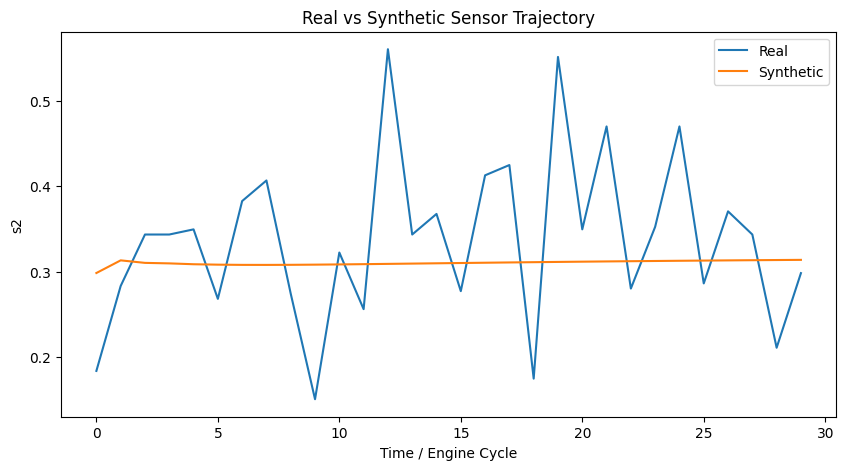

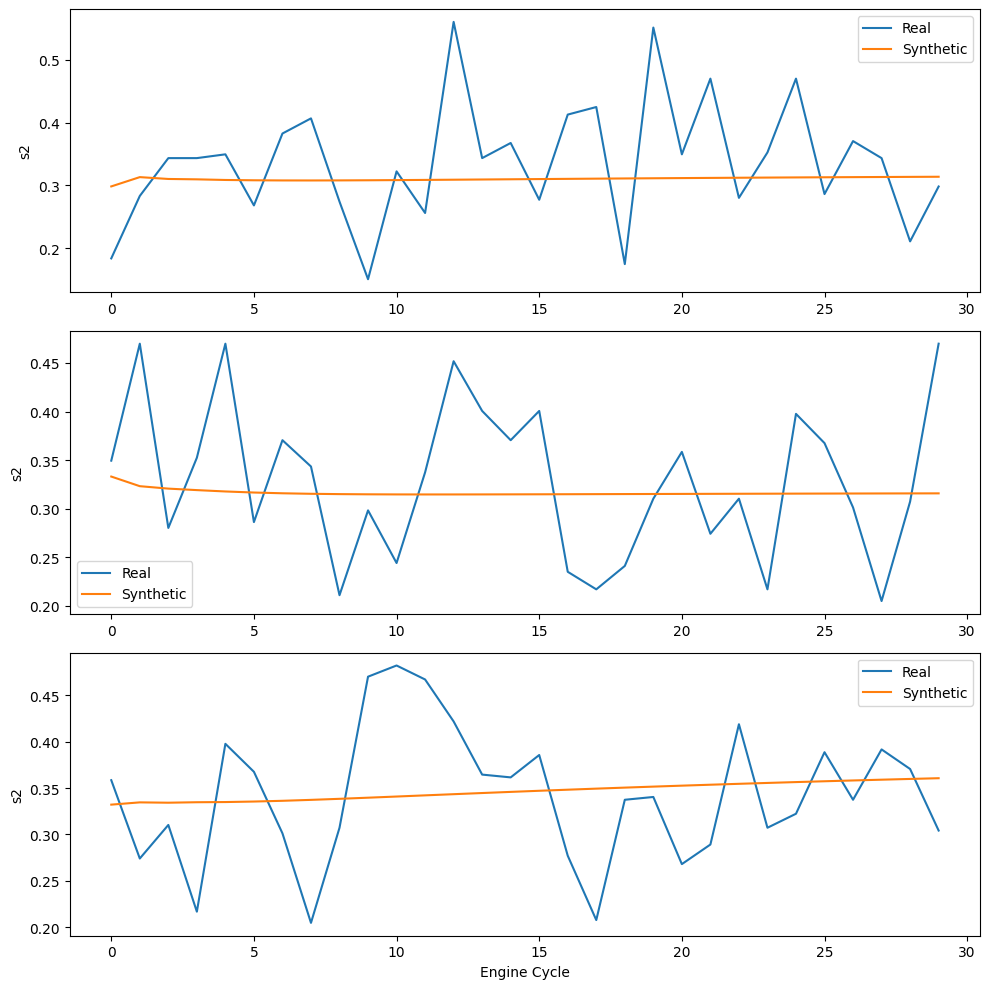

In [ ]:
sensor_index = 0

plt.figure(figsize=(10, 5))

plt.plot(
    X_train[0, :, sensor_index],
    label="Real"
)

plt.plot(
    X_synthetic[0, :, sensor_index],
    label="Synthetic"
)

plt.xlabel("Time / Engine Cycle")
plt.ylabel(useful_sensors[sensor_index])
plt.title("Real vs Synthetic Sensor Trajectory")
plt.legend()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

for i, ax in enumerate(axes):

    idx = i * 20

    ax.plot(
        X_train[idx, :, sensor_index],
        label="Real"
    )

    ax.plot(
        X_synthetic[idx, :, sensor_index],
        label="Synthetic"
    )

    ax.set_ylabel(useful_sensors[sensor_index])
    ax.legend()

axes[-1].set_xlabel("Engine Cycle")

plt.tight_layout()
plt.show()

In [ ]:
def build_rul_model():

    model = tf.keras.Sequential([
        layers.Input(
            shape=(WINDOW, n_features)
        ),

        layers.LSTM(
            64,
            return_sequences=True
        ),

        layers.Dropout(0.2),

        layers.LSTM(32),

        layers.Dense(32, activation="relu"),

        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="mse",
        metrics=["mae"]
    )

    return model


baseline_model = build_rul_model()

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,729 (131.75 KB)

 Trainable params: 33,729 (131.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 6291.5703 - mae: 68.3867 - val_loss: 5137.8911 - val_mae: 61.9522
Epoch 2/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3106.5581 - mae: 47.5533 - val_loss: 2328.6396 - val_mae: 43.2190
Epoch 3/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1835.6564 - mae: 38.2002 - val_loss: 1806.4824 - val_mae: 38.4277
Epoch 4/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1740.7269 - mae: 37.0700 - val_loss: 1779.0867 - val_mae: 38.0133
Epoch 5/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1740.3530 - mae: 37.0148 - val_loss: 1776.9667 - val_mae: 37.9763
Epoch 6/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1740.0929 - mae: 37.0120 - val_loss: 1783.9673 - val_mae: 38.0936
Epoch 7/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1740.2388 - mae: 37.0229 - val_loss: 1780.6764 - val_mae: 38.0402
Epoch 8/30
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1740.2034 - mae: 37.0241 - val_loss: 1782.7672 - val

In [ ]:
X_augmented = np.concatenate(
    [X_train, X_synthetic],
    axis=0
)

y_augmented = np.concatenate(
    [y_train, y_synthetic],
    axis=0
)

print("Original dataset :", X_train.shape)
print("Augmented dataset:", X_augmented.shape)

augmented_model = build_rul_model()

augmented_history = augmented_model.fit(
    X_augmented,
    y_augmented,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Original dataset : (13818, 30, 14)
Augmented dataset: (27636, 30, 14)
Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4915.8779 - mae: 59.3946 - val_loss: 2671.5239 - val_mae: 45.7793
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1861.4366 - mae: 38.3431 - val_loss: 1789.8715 - val_mae: 38.1878
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 1740.2585 - mae: 37.0301 - val_loss: 1778.6487 - val_mae: 38.0058
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1740.1592 - mae: 37.0148 - val_loss: 1781.0583 - val_mae: 38.0465
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1740.2043 - mae: 37.0194 - val_loss: 1779.9750 - val_mae: 38.0284


In [ ]:
def make_test_sequences(test_df, rul_values, window=30):

    X = []
    y = []

    for idx, unit in enumerate(
        sorted(test_df["unit"].unique())
    ):

        engine = test_df[
            test_df["unit"] == unit
        ].sort_values("cycle")

        values = engine[
            useful_sensors
        ].values

        # True RUL at final observed cycle
        final_rul = float(
            rul_values[idx]
        )

        total_cycles = len(engine)

        # Only use the final available window
        sequence = values[
            -window:
        ]

        # RUL at the end of the window
        y_true = final_rul

        X.append(sequence)
        y.append(y_true)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


X_test, y_test = make_test_sequences(
    test,
    true_rul["RUL"].values,
    WINDOW
)

print("Test:", X_test.shape)
print("RUL :", y_test.shape)

Test: (100, 30, 14)
RUL : (100,)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_pred = baseline_model.predict(
    X_test,
    verbose=0
).flatten()

augmented_pred = augmented_model.predict(
    X_test,
    verbose=0
).flatten()

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

augmented_mae = mean_absolute_error(
    y_test,
    augmented_pred
)

augmented_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        augmented_pred
    )
)

augmented_r2 = r2_score(
    y_test,
    augmented_pred
)

results = pd.DataFrame({
    "Model": [
        "LSTM - Real Data",
        "LSTM - Real + VAE Synthetic"
    ],

    "MAE": [
        baseline_mae,
        augmented_mae
    ],

    "RMSE": [
        baseline_rmse,
        augmented_rmse
    ],

    "R2": [
        baseline_r2,
        augmented_r2
    ]
})

print(results)

                         Model        MAE       RMSE        R2
0             LSTM - Real Data  12.078453  16.300673  0.846131
1  LSTM - Real + VAE Synthetic  41.074535  46.589917 -0.256968


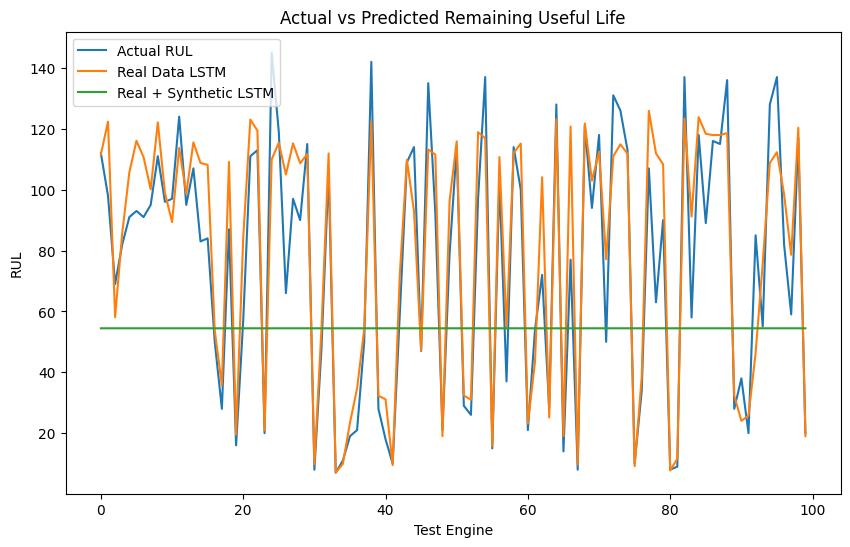

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    y_test,
    label="Actual RUL"
)

plt.plot(
    baseline_pred,
    label="Real Data LSTM"
)

plt.plot(
    augmented_pred,
    label="Real + Synthetic LSTM"
)

plt.xlabel("Test Engine")
plt.ylabel("RUL")
plt.title("Actual vs Predicted Remaining Useful Life")
plt.legend()
plt.show()

In [ ]:
mae_improvement = (
    (baseline_mae - augmented_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - augmented_rmse)
    / baseline_rmse
) * 100

print(
    f"MAE improvement: {mae_improvement:.2f}%"
)

print(
    f"RMSE improvement: {rmse_improvement:.2f}%"
)

MAE improvement: -240.06%
RMSE improvement: -185.82%


   Synthetic Fraction        MAE       RMSE
0                0.25  49.498295  58.505665
1                0.50  43.409813  49.881148
2                1.00  39.428078  44.183751


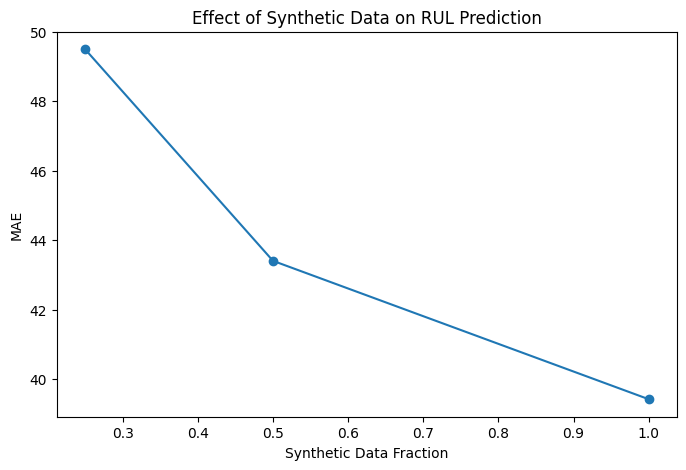

In [ ]:
fractions = [0.25, 0.50, 1.00]

augmentation_results = []

for fraction in fractions:

    n_synth = int(
        len(X_synthetic) * fraction
    )

    X_mix = np.concatenate(
        [
            X_train,
            X_synthetic[:n_synth]
        ]
    )

    y_mix = np.concatenate(
        [
            y_train,
            y_synthetic[:n_synth]
        ]
    )

    model = build_rul_model()

    model.fit(
        X_mix,
        y_mix,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=128,
        callbacks=[early_stop],
        verbose=0
    )

    pred = model.predict(
        X_test,
        verbose=0
    ).flatten()

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    augmentation_results.append({
        "Synthetic Fraction": fraction,
        "MAE": mae,
        "RMSE": rmse
    })

augmentation_df = pd.DataFrame(
    augmentation_results
)

print(augmentation_df)

plt.figure(figsize=(8, 5))

plt.plot(
    augmentation_df["Synthetic Fraction"],
    augmentation_df["MAE"],
    marker="o"
)

plt.xlabel("Synthetic Data Fraction")
plt.ylabel("MAE")
plt.title("Effect of Synthetic Data on RUL Prediction")
plt.show()

In [ ]:
baseline_model.save(
    "/content/rul_lstm_baseline.keras"
)

augmented_model.save(
    "/content/rul_lstm_augmented.keras"
)

print("Models saved successfully.")

Models saved successfully.


In [ ]:
encoder.save(
    "/content/encoder.keras"
)

decoder.save(
    "/content/decoder.keras"
)

baseline_model.save(
    "/content/rul_lstm_baseline.keras"
)

augmented_model.save(
    "/content/rul_lstm_augmented.keras"
)

print("Saved successfully")

Saved successfully
